<a href="https://colab.research.google.com/github/youkjang/gefs-heavy-precip-verification/blob/main/notebooks/04_multi_case_brier_score_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multi-Case Brier Score Verification of GEFS Heavy Precipitation Forecasts

###Single-case Brier Score workflow ▶ multiple GEFS forecast initialization dates

- Goal: evaluate probabilistic heavy precipitation forecasts across several cases rather than relying on one forecast example.

###The workflow includes:

- opening GEFS accumulated precipitation forecasts for multiple initialization dates
- computing ensemble probability of precipitation exceeding 25 mm
- loading CPC observed daily precipitation for the forecast valid date
- interpolating observations to the GEFS grid
- computing Brier Score for each case
- comparing CONUS-averaged Brier Score across forecast dates

- Obsserved precipitation: https://psl.noaa.gov/thredds/catalog/catalog.html



##1. Install packages

In [1]:
!pip install cartopy

In [2]:
!pip -q install "eccodes>=2.37.0" cfgrib s3fs "fsspec==2025.3.0"

##2. Import Libraries

In [3]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import s3fs
from pathlib import Path
import cartopy.crs as ccrs

##3. Set configuration
14 dates, 11 members, one threshold, and one lead time

In [4]:
# GEFS configuration
cycle = "00"    # Forecast initialization cycle in UTC
fhr = 24        # Forecast lead time in hours; valid time = initialization time + fhr
threshold_mm = 25.0

# Start small first
init_dates = [
    "20260510",
    "20260511",
    "20260512",
    "20260513",
    "20260514",
    "20260515",
    "20260516",
    "20260517",
    "20260518",
    "20260519",
    "20260520",
    "20260521",
    "20260522",
    "20260523"
]

# Starter ensemble: control + 10 perturbed members
members = ["c00"] + [f"p{i:02d}" for i in range(1, 11)]

# Directories
cache_dir = Path("/content/gefs_precip_cache")
cache_dir.mkdir(exist_ok=True)

fig_dir = Path("figures")
fig_dir.mkdir(exist_ok=True)

# S3 access
fs = s3fs.S3FileSystem(anon=True)

##4. Function: open one GEFS precipitation member

In [5]:
def open_gefs_precip_member(init_date, cycle, member, fhr):
    """
    Open GEFS accumulated precipitation for one member and one forecast hour.

    Returns
    -------
    xarray.DataArray
        CONUS accumulated precipitation in mm.
    """

    fname = f"ge{member}.t{cycle}z.pgrb2a.0p50.f{fhr:03d}"

    s3_key = (
        f"noaa-gefs-pds/gefs.{init_date}/{cycle}/atmos/pgrb2ap5/"
        f"{fname}"
    )

    local_file = cache_dir / fname

    if not local_file.exists():
        print(f"Downloading {fname}")
        fs.get(s3_key, str(local_file))
    else:
        print(f"Using cached file: {fname}")

    ds = xr.open_dataset(
        local_file,
        engine="cfgrib",
        backend_kwargs={
            "filter_by_keys": {
                "typeOfLevel": "surface",
                "stepType": "accum"
            },
            "indexpath": ""
        }
    )

    if "tp" not in ds.data_vars:
        raise ValueError(f"'tp' not found. Available variables: {list(ds.data_vars)}")

    precip = ds["tp"]

    # Convert longitude from 0–360 to -180–180
    precip = precip.assign_coords(
        longitude=((precip.longitude + 180) % 360) - 180
    ).sortby("longitude")

    # Subset CONUS
    if precip.latitude[0] > precip.latitude[-1]:
        precip_us = precip.sel(
            longitude=slice(-125, -66),
            latitude=slice(50, 24)
        )
    else:
        precip_us = precip.sel(
            longitude=slice(-125, -66),
            latitude=slice(24, 50)
        )

    precip_us = precip_us.squeeze()
    precip_us.attrs["units"] = "mm"
    precip_us.attrs["long_name"] = "Accumulated precipitation"

    return precip_us

##5. Function: compute GEFS probability of heavy precipitation

In [6]:
def compute_gefs_probability(init_date, cycle, fhr, members, threshold_mm):
    """
    Load multiple GEFS precipitation members and compute probability of exceeding threshold.

    Returns
    -------
    prob_heavy : xarray.DataArray
        Probability as fraction from 0 to 1.
    precip_ens : xarray.DataArray
        Ensemble precipitation with member dimension.
    """

    precip_members = []

    for member in members:
        print(f"Opening {init_date} member {member}")

        da = open_gefs_precip_member(
            init_date=init_date,
            cycle=cycle,
            member=member,
            fhr=fhr
        )

        da = da.expand_dims(member=[member])
        precip_members.append(da)

    precip_ens = xr.concat(precip_members, dim="member")

    # Boolean event for each member
    heavy_event_fcst = precip_ens >= threshold_mm

    # Probability as fraction, not percent
    prob_heavy = heavy_event_fcst.mean(dim="member")

    prob_heavy.attrs["units"] = "fraction"
    prob_heavy.attrs["long_name"] = f"GEFS probability of precipitation ≥ {threshold_mm} mm"

    return prob_heavy, precip_ens

##6. Function: open CPC observed precipitation

In [7]:
def open_cpc_observed_precip(valid_date):
    """
    Open CPC Unified Gauge-Based Daily Precipitation for the valid date.

    Parameters
    ----------
    valid_date : str
        Date in YYYY-MM-DD format.

    Returns
    -------
    obs_us : xarray.DataArray
        Observed daily precipitation over CONUS in mm.
    """

    valid_time = pd.to_datetime(valid_date)
    year = valid_time.year

    ##The link of obs_url does not work
    ##The local file is used.

    # obs_url = (
    #     f"https://psl.noaa.gov/thredds/dodsC/"
    #     f"Datasets/cpc_us_precip/RT/precip.V1.0.{year}.nc"
    # )

    obs_url = (f"/content/precip.V1.0.{year}.nc")

    print("Opening observed precipitation:")
    print(obs_url)


    obs_ds = xr.open_dataset(obs_url)


    if "precip" not in obs_ds.data_vars:
        raise ValueError(f"'precip' not found. Available variables: {list(obs_ds.data_vars)}")

    obs_precip = obs_ds["precip"]

    # Select valid date
    obs_day = obs_precip.sel(time=valid_date, method="nearest")

    # Convert longitude if needed
    if obs_day.lon.max() > 180:
        obs_day = obs_day.assign_coords(
            lon=((obs_day.lon + 180) % 360) - 180
        ).sortby("lon")

    # Subset CONUS
    if obs_day.lat[0] > obs_day.lat[-1]:
        obs_us = obs_day.sel(
            lon=slice(-125, -66),
            lat=slice(50, 24)
        )
    else:
        obs_us = obs_day.sel(
            lon=slice(-125, -66),
            lat=slice(24, 50)
        )

    obs_us.attrs["units"] = "mm"
    obs_us.attrs["long_name"] = "Observed daily precipitation"

    return obs_us

##7. Function: compute Brier Score for one case

In [8]:
def compute_case_brier_score(init_date, cycle, fhr, members, threshold_mm):
    """
    Compute CONUS-averaged Brier Score for one GEFS forecast initialization.

    Returns
    -------
    dict
        Case summary including date, valid date, threshold, and mean Brier Score.
    """

    print("\n" + "="*70)
    print(f"Processing initialization date: {init_date}")
    print("="*70)

    # Forecast valid date
    valid_time = pd.to_datetime(init_date, format="%Y%m%d") + pd.Timedelta(hours=fhr)
    valid_date = valid_time.strftime("%Y-%m-%d")

    print(f"Forecast valid date: {valid_date}")

    # GEFS probability forecast
    prob_heavy, precip_ens = compute_gefs_probability(
        init_date=init_date,
        cycle=cycle,
        fhr=fhr,
        members=members,
        threshold_mm=threshold_mm
    )

    # Observed precipitation
    obs_us = open_cpc_observed_precip(valid_date)

    # Rename observed coordinates to match GEFS
    obs_us = obs_us.rename({"lat": "latitude", "lon": "longitude"})

    # Interpolate observations to GEFS grid
    obs_on_gefs = obs_us.interp(
        latitude=prob_heavy.latitude,
        longitude=prob_heavy.longitude
    )

    # Observed binary event
    obs_event = (obs_on_gefs >= threshold_mm).astype(float)

    # Brier Score
    brier_score = (prob_heavy - obs_event) ** 2

    # Area-weighted CONUS mean
    weights = np.cos(np.deg2rad(brier_score.latitude))
    weights.name = "weights"

    mean_bs = brier_score.weighted(weights).mean(
        dim=("latitude", "longitude")
    )

    mean_bs_value = float(mean_bs.values)

    print(f"CONUS mean Brier Score: {mean_bs_value:.3f}")

    return {
        "init_date": init_date,
        "valid_date": valid_date,
        "cycle": cycle,
        "forecast_hour": fhr,
        "lead_day": fhr / 24,
        "threshold_mm": threshold_mm,
        "n_members": len(members),
        "mean_brier_score": mean_bs_value
    }

##8. Run multi-case Brier Score loop

In [9]:
case_results = []

for init_date in init_dates:
    try:
        result = compute_case_brier_score(
            init_date=init_date,
            cycle=cycle,
            fhr=fhr,
            members=members,
            threshold_mm=threshold_mm
        )
        case_results.append(result)

    except Exception as e:
        print(f"FAILED for {init_date}")
        print(e)

bs_df = pd.DataFrame(case_results)
bs_df


Processing initialization date: 20260510
Forecast valid date: 2026-05-11
Opening 20260510 member c00
Using cached file: gec00.t00z.pgrb2a.0p50.f024
Opening 20260510 member p01
Using cached file: gep01.t00z.pgrb2a.0p50.f024
Opening 20260510 member p02
Using cached file: gep02.t00z.pgrb2a.0p50.f024
Opening 20260510 member p03
Using cached file: gep03.t00z.pgrb2a.0p50.f024
Opening 20260510 member p04
Using cached file: gep04.t00z.pgrb2a.0p50.f024
Opening 20260510 member p05
Using cached file: gep05.t00z.pgrb2a.0p50.f024
Opening 20260510 member p06
Using cached file: gep06.t00z.pgrb2a.0p50.f024
Opening 20260510 member p07
Using cached file: gep07.t00z.pgrb2a.0p50.f024
Opening 20260510 member p08
Using cached file: gep08.t00z.pgrb2a.0p50.f024
Opening 20260510 member p09
Using cached file: gep09.t00z.pgrb2a.0p50.f024
Opening 20260510 member p10
Using cached file: gep10.t00z.pgrb2a.0p50.f024


/tmp/ipykernel_28051/3119587175.py:28: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  precip_ens = xr.concat(precip_members, dim="member")


Opening observed precipitation:
/content/precip.V1.0.2026.nc
CONUS mean Brier Score: 0.005

Processing initialization date: 20260511
Forecast valid date: 2026-05-12
Opening 20260511 member c00
Using cached file: gec00.t00z.pgrb2a.0p50.f024
Opening 20260511 member p01
Using cached file: gep01.t00z.pgrb2a.0p50.f024
Opening 20260511 member p02
Using cached file: gep02.t00z.pgrb2a.0p50.f024
Opening 20260511 member p03
Using cached file: gep03.t00z.pgrb2a.0p50.f024
Opening 20260511 member p04
Using cached file: gep04.t00z.pgrb2a.0p50.f024
Opening 20260511 member p05
Using cached file: gep05.t00z.pgrb2a.0p50.f024
Opening 20260511 member p06
Using cached file: gep06.t00z.pgrb2a.0p50.f024
Opening 20260511 member p07
Using cached file: gep07.t00z.pgrb2a.0p50.f024
Opening 20260511 member p08
Using cached file: gep08.t00z.pgrb2a.0p50.f024
Opening 20260511 member p09
Using cached file: gep09.t00z.pgrb2a.0p50.f024
Opening 20260511 member p10
Using cached file: gep10.t00z.pgrb2a.0p50.f024


/tmp/ipykernel_28051/3119587175.py:28: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  precip_ens = xr.concat(precip_members, dim="member")


Opening observed precipitation:
/content/precip.V1.0.2026.nc
CONUS mean Brier Score: 0.004

Processing initialization date: 20260512
Forecast valid date: 2026-05-13
Opening 20260512 member c00
Using cached file: gec00.t00z.pgrb2a.0p50.f024
Opening 20260512 member p01
Using cached file: gep01.t00z.pgrb2a.0p50.f024
Opening 20260512 member p02
Using cached file: gep02.t00z.pgrb2a.0p50.f024
Opening 20260512 member p03
Using cached file: gep03.t00z.pgrb2a.0p50.f024
Opening 20260512 member p04
Using cached file: gep04.t00z.pgrb2a.0p50.f024
Opening 20260512 member p05
Using cached file: gep05.t00z.pgrb2a.0p50.f024
Opening 20260512 member p06
Using cached file: gep06.t00z.pgrb2a.0p50.f024
Opening 20260512 member p07
Using cached file: gep07.t00z.pgrb2a.0p50.f024
Opening 20260512 member p08
Using cached file: gep08.t00z.pgrb2a.0p50.f024
Opening 20260512 member p09
Using cached file: gep09.t00z.pgrb2a.0p50.f024
Opening 20260512 member p10
Using cached file: gep10.t00z.pgrb2a.0p50.f024


...

Opening observed precipitation:
/content/precip.V1.0.2026.nc
CONUS mean Brier Score: 0.016

Processing initialization date: 20260522
Forecast valid date: 2026-05-23
Opening 20260522 member c00
Using cached file: gec00.t00z.pgrb2a.0p50.f024
Opening 20260522 member p01
Using cached file: gep01.t00z.pgrb2a.0p50.f024
Opening 20260522 member p02
Using cached file: gep02.t00z.pgrb2a.0p50.f024
Opening 20260522 member p03
Using cached file: gep03.t00z.pgrb2a.0p50.f024
Opening 20260522 member p04
Using cached file: gep04.t00z.pgrb2a.0p50.f024
Opening 20260522 member p05
Using cached file: gep05.t00z.pgrb2a.0p50.f024
Opening 20260522 member p06
Using cached file: gep06.t00z.pgrb2a.0p50.f024
Opening 20260522 member p07
Using cached file: gep07.t00z.pgrb2a.0p50.f024
Opening 20260522 member p08
Using cached file: gep08.t00z.pgrb2a.0p50.f024
Opening 20260522 member p09
Using cached file: gep09.t00z.pgrb2a.0p50.f024
Opening 20260522 member p10
Using cached file: gep10.t00z.pgrb2a.0p50.f024


/tmp/ipykernel_28051/3119587175.py:28: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  precip_ens = xr.concat(precip_members, dim="member")


Opening observed precipitation:
/content/precip.V1.0.2026.nc
CONUS mean Brier Score: 0.026

Processing initialization date: 20260523
Forecast valid date: 2026-05-24
Opening 20260523 member c00
Using cached file: gec00.t00z.pgrb2a.0p50.f024
Opening 20260523 member p01
Using cached file: gep01.t00z.pgrb2a.0p50.f024
Opening 20260523 member p02
Using cached file: gep02.t00z.pgrb2a.0p50.f024
Opening 20260523 member p03
Using cached file: gep03.t00z.pgrb2a.0p50.f024
Opening 20260523 member p04
Using cached file: gep04.t00z.pgrb2a.0p50.f024
Opening 20260523 member p05
Using cached file: gep05.t00z.pgrb2a.0p50.f024
Opening 20260523 member p06
Using cached file: gep06.t00z.pgrb2a.0p50.f024
Opening 20260523 member p07
Using cached file: gep07.t00z.pgrb2a.0p50.f024
Opening 20260523 member p08
Using cached file: gep08.t00z.pgrb2a.0p50.f024
Opening 20260523 member p09
Using cached file: gep09.t00z.pgrb2a.0p50.f024
Opening 20260523 member p10
Using cached file: gep10.t00z.pgrb2a.0p50.f024
Opening ob

/tmp/ipykernel_28051/3119587175.py:28: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  precip_ens = xr.concat(precip_members, dim="member")


,init_date,valid_date,cycle,forecast_hour,lead_day,threshold_mm,n_members,mean_brier_score
0,20260510,2026-05-11,00,24,1.0,25.0,11,0.004937
1,20260511,2026-05-12,00,24,1.0,25.0,11,0.003582
2,20260512,2026-05-13,00,24,1.0,25.0,11,0.002749
3,20260513,2026-05-14,00,24,1.0,25.0,11,0.001215
4,20260514,2026-05-15,00,24,1.0,25.0,11,0.004072
5,20260515,2026-05-16,00,24,1.0,25.0,11,0.000548
6,20260516,2026-05-17,00,24,1.0,25.0,11,0.006824
7,20260517,2026-05-18,00,24,1.0,25.0,11,0.007929
8,20260518,2026-05-19,00,24,1.0,25.0,11,0.021858
9,20260519,2026-05-20,00,24,1.0,25.0,11,0.021464


##10. Plot Brier Score by forecast initialization date

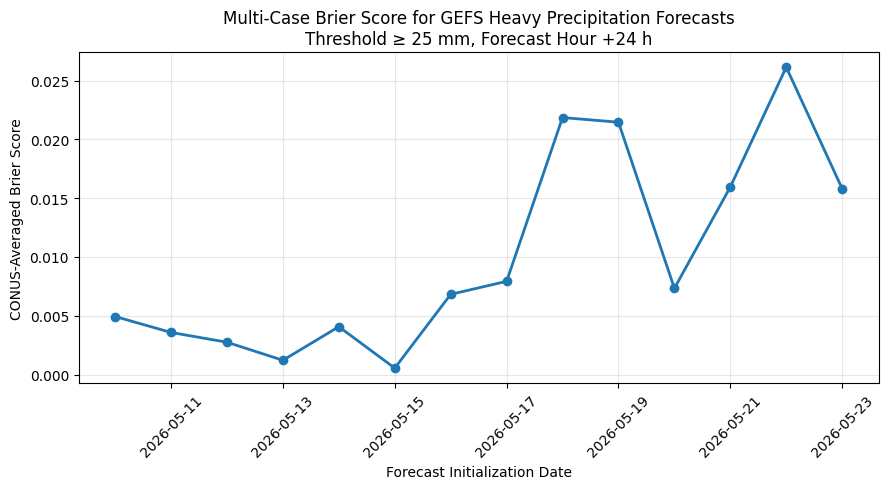

In [10]:
plt.figure(figsize=(9, 5))

plt.plot(
    pd.to_datetime(bs_df["init_date"]),
    bs_df["mean_brier_score"],
    marker="o",
    linewidth=2
)

plt.xlabel("Forecast Initialization Date")
plt.ylabel("CONUS-Averaged Brier Score")
plt.title(
    f"Multi-Case Brier Score for GEFS Heavy Precipitation Forecasts\n"
    f"Threshold ≥ {threshold_mm:.0f} mm, Forecast Hour +{fhr} h"
)

plt.grid(alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("figures/multi_case_brier_score_25mm.png", dpi=150, bbox_inches="tight")
plt.show()

##11. Summary statistics

In [11]:
mean_bs_all = bs_df["mean_brier_score"].mean()
min_bs = bs_df["mean_brier_score"].min()
max_bs = bs_df["mean_brier_score"].max()

print(f"Mean Brier Score across cases: {mean_bs_all:.3f}")
print(f"Minimum Brier Score: {min_bs:.3f}")
print(f"Maximum Brier Score: {max_bs:.3f}")

Mean Brier Score across cases: 0.010
Minimum Brier Score: 0.001
Maximum Brier Score: 0.026



##Discussion
- The CONUS-averaged Brier Score varies with different initialization dates.
- Larger values: the GEFS probability forecast had greater error for the ≥25 mm precipitation event.
- Small values: heavy precipitation is spatially rare, so the domain-averaged Brier Score remains small ▶ The large number of no-event grid points influence this small score.

###Note on AI Assistance

This notebook was developed with AI-assisted coding support. See the repository README for details.